# TTC Subway Delay Data — Preprocessing & Exploratory Analysis

**Author:** Suha Islaih  
**Date:** February 2026  
**Dataset:** Toronto Transit Commission (TTC) subway delay records, 2024–2025  

## Objective

Prepare TTC subway delay data for a regression model that predicts **delay duration in minutes** for a given line, station, time, and day.

## Approach

| Step | Description |
|------|-------------|
| **1. Data Loading** | Combine 2024 (Excel) and 2025 (CSV) delay records into a single dataset |
| **2. Data Cleaning** | Standardize line names, remove invalid records, handle outliers, drop irrelevant columns |
| **3. Feature Engineering** | Extract temporal features, compute historical average delays per route/time |
| **4. Correlation Analysis** | Identify data leakage, multicollinearity, and useful predictors |
| **5. Exploratory Data Analysis** | Visualize delay patterns by time, day, line, station, and incident code |
| **6. Export** | Save the cleaned dataset for model training |

## Target Variable

`min_delay_capped` — delay in minutes, capped at 60 to mitigate extreme outliers.

---

## Step 1: Data Loading

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [18]:
df_2024 = pd.read_excel('./data/ttc-subway-delay-2024.xlsx', sheet_name='Subway')
df_2025 = pd.read_csv('./data/ttc-subway-delay-data-since-2025.csv')

In [19]:
#pip install openpyxl

In [20]:
df = pd.concat([df_2024,df_2025], ignore_index = True)
print (f"Combined dataset: {df.shape[0]:,} records, {df.shape[1]} columns")

Combined dataset: 52,180 records, 11 columns


In [21]:
df.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,_id
0,2024-01-01 00:00:00,02:00,Monday,SHEPPARD STATION,MUI,0,0,N,YU,5491,NaN
1,2024-01-01 00:00:00,02:00,Monday,DUNDAS STATION,MUIS,0,0,N,YU,0,NaN
2,2024-01-01 00:00:00,02:08,Monday,DUNDAS STATION,MUPAA,4,10,N,YU,6051,NaN
3,2024-01-01 00:00:00,02:13,Monday,KENNEDY BD STATION,PUTDN,10,16,E,BD,5284,NaN
4,2024-01-01 00:00:00,02:22,Monday,BLOOR STATION,MUPAA,4,10,N,YU,5986,NaN


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52180 entries, 0 to 52179
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       52180 non-null  object 
 1   Time       52180 non-null  object 
 2   Day        52180 non-null  object 
 3   Station    52180 non-null  object 
 4   Code       52180 non-null  object 
 5   Min Delay  52180 non-null  int64  
 6   Min Gap    52180 non-null  int64  
 7   Bound      42660 non-null  object 
 8   Line       52136 non-null  object 
 9   Vehicle    52180 non-null  int64  
 10  _id        25713 non-null  float64
dtypes: float64(1), int64(3), object(7)
memory usage: 4.4+ MB


## Step 2: Data Cleaning

In [23]:
print(f"Unique Line values before cleaning: {df['Line'].unique()}")
df['Line'].value_counts()

Unique Line values before cleaning: ['YU' 'BD' 'YUS' 'YU/BD' 'SHP' nan 'BLOOR DANFORTH' 'YU / BD' 'YU/ BD'
 'SRT' 'YUS/BD' 'SHEP' 'LINE 1' 'TRACK LEVEL ACTIVITY' 'YU & BD'
 '109 RANEE' 'ONGE-UNIVERSITY AND BL' 'YU/BD/SHP' 'BD/ YUS' 'BD/ YU'
 'BD/YU' 'BD / YU' '20 CLIFFSIDE' 'None' 'YUS/ BD' 'BD/YUS' 'YUS/ BD/ SHP'
 'YUS / BD' 'YU -BD LINES' '29 DUFFERIN' 'YU/BD LINES']


YU                        27221
BD                        22133
SHP                        1955
YU/BD                       655
None                         67
YUS/BD                       24
YU/ BD                       20
YUS                          11
YU / BD                      11
BD/YU                         7
YU & BD                       6
SRT                           3
BD/YUS                        3
YUS / BD                      2
YU/BD/SHP                     2
YU/BD LINES                   2
109 RANEE                     1
BD/ YUS                       1
BD/ YU                        1
TRACK LEVEL ACTIVITY          1
BD / YU                       1
20 CLIFFSIDE                  1
LINE 1                        1
YUS/ BD                       1
SHEP                          1
YUS/ BD/ SHP                  1
BLOOR DANFORTH                1
YU -BD LINES                  1
29 DUFFERIN                   1
ONGE-UNIVERSITY AND BL        1
Name: Line, dtype: int64

In [24]:
line_mapping = {
    # Line 1 — Yonge-University
    'YU': 'Line 1', 'YUS': 'Line 1', 'LINE 1': 'Line 1',
    # Line 2 — Bloor-Danforth
    'BD': 'Line 2', 'BLOOR DANFORTH': 'Line 2',
    # Line 4 — Sheppard
    'SHP': 'Line 4', 'SHEP': 'Line 4',
    # Line 3 — Scarborough RT (decommissioned 2023)
    'SRT': 'Line 3',
    # Multi-line: Line 1 / Line 2
    'YU/BD': 'Line 1/2', 'YU/ BD': 'Line 1/2', 'YU / BD': 'Line 1/2',
    'YU & BD': 'Line 1/2', 'YU/BD LINES': 'Line 1/2', 'YU -BD LINES': 'Line 1/2',
    'BD/YU': 'Line 1/2', 'BD/ YU': 'Line 1/2', 'BD / YU': 'Line 1/2',
    'YUS/BD': 'Line 1/2', 'YUS / BD': 'Line 1/2', 'YUS/ BD': 'Line 1/2',
    'BD/YUS': 'Line 1/2', 'BD/ YUS': 'Line 1/2', 'ONGE-UNIVERSITY AND BL': 'Line 1/2',
    # Multi-line: Line 1 / Line 2 / Line 4
    'YU/BD/SHP': 'Line 1/2/4', 'YUS/ BD/ SHP': 'Line 1/2/4',
    # Invalid — bus routes and non-subway entries
    '109 RANEE': None, '20 CLIFFSIDE': None, '29 DUFFERIN': None, 'TRACK LEVEL ACTIVITY': None,
}

In [25]:
df['Line'] = df['Line'].map(line_mapping)
print(f"Unique Line values after maping: {df['Line'].dropna().nunique()}")
df['Line'].value_counts()

Unique Line values after maping: 6


Line 1        27233
Line 2        22134
Line 4         1956
Line 1/2        736
Line 3            3
Line 1/2/4        3
Name: Line, dtype: int64

In [27]:
df.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,_id
0,2024-01-01 00:00:00,02:00,Monday,SHEPPARD STATION,MUI,0,0,N,Line 1,5491,NaN
1,2024-01-01 00:00:00,02:00,Monday,DUNDAS STATION,MUIS,0,0,N,Line 1,0,NaN
2,2024-01-01 00:00:00,02:08,Monday,DUNDAS STATION,MUPAA,4,10,N,Line 1,6051,NaN
3,2024-01-01 00:00:00,02:13,Monday,KENNEDY BD STATION,PUTDN,10,16,E,Line 2,5284,NaN
4,2024-01-01 00:00:00,02:22,Monday,BLOOR STATION,MUPAA,4,10,N,Line 1,5986,NaN


### 2.2 Remove Invalid Records

In [28]:
records_before = len(df)
df = df.dropna(subset=['Line'])
print(f"Removed {records_before - len(df)} invalid records ({records_before:,} -> {len(df):,})")

Removed 115 invalid records (52,180 -> 52,065)


## Outliers Detection - Min Delay

In [29]:
df.describe()

,Min Delay,Min Gap,Vehicle,_id
count,52065.000000,52065.000000,52065.000000,25645.000000
mean,2.784366,4.018285,3218.378469,12848.169039
std,10.610422,11.310750,2741.180706,7420.059583
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,6421.000000
50%,0.000000,0.000000,5115.000000,12845.000000
75%,4.000000,8.000000,5581.000000,19269.000000
max,900.000000,906.000000,9546.000000,25713.000000


In [30]:
print(df["Min Delay"].describe().round(2))

count    52065.00
mean         2.78
std         10.61
min          0.00
25%          0.00
50%          0.00
75%          4.00
max        900.00
Name: Min Delay, dtype: float64


## IQR Method - Determining the Vap Value
The **Interquartile Range (IQR)** measures the spread of the middle 50% of the data.
It is used here to calculate a statistically grounded cap value for `min_delay_capped`,
rather than choosing a number arbitrarily.

- **Q1** — 25th percentile (bottom quarter of delays)
- **Q3** — 75th percentile (top quarter of delays)
- **IQR** = Q3 − Q1
- **Upper fence** = Q3 + 1.5 × IQR — any value above this is considered an outlier


In [31]:
# 25th and 75th percentiles — define the middle 50% of the data
Q1 = df['Min Delay'].quantile(0.25)
Q3 = df['Min Delay'].quantile(0.75)

# IQR: spread of the middle 50%
IQR = Q3 - Q1

# Upper fence: standard threshold beyond which a value is an outlier
upper_fence = Q3 + 1.5 * IQR

print(f"Q1 = {Q1} min")
print(f"Q3 = {Q3} min")
print(f"IQR = {IQR} min")
print(f"Upper fence (Q3 + 1.5 × IQR) = {upper_fence} min")
print(f"\nAny delay above {upper_fence} min will be capped.")

Q1 = 0.0 min
Q3 = 4.0 min
IQR = 4.0 min
Upper fence (Q3 + 1.5 × IQR) = 10.0 min

Any delay above 10.0 min will be capped.


In [32]:
df['min_delay_capped'] = df['Min Delay'].clip(upper=upper_fence)

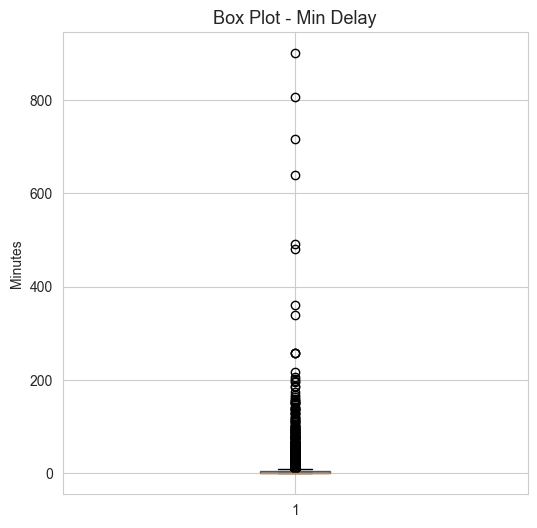

In [33]:
plt.figure(figsize=(6,6))
plt.boxplot(df['Min Delay'],
            vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Box Plot - Min Delay', fontsize=13)
plt.ylabel('Minutes')
plt.show()


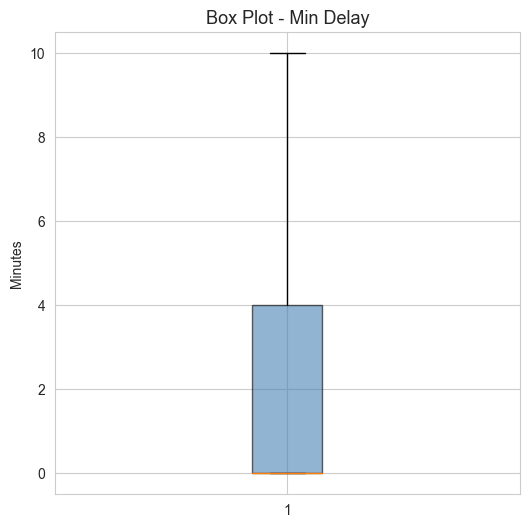

In [34]:
plt.figure(figsize=(6,6))
plt.boxplot(df['min_delay_capped'],
            vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Box Plot - Min Delay', fontsize=13)
plt.ylabel('Minutes')
plt.show()

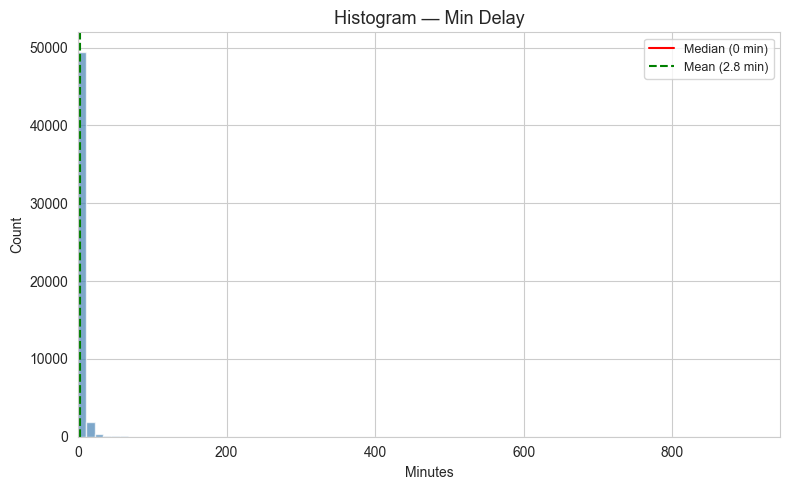

In [35]:
# Histogram — Min Delay
plt.figure(figsize=(8, 5))
plt.hist(df['Min Delay'], bins=80, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(df['Min Delay'].median(), color='red', linestyle='-', linewidth=1.5,
            label=f'Median ({df["Min Delay"].median():.0f} min)')
plt.axvline(df['Min Delay'].mean(), color='green', linestyle='--', linewidth=1.5,
            label=f'Mean ({df["Min Delay"].mean():.1f} min)')
plt.title('Histogram — Min Delay', fontsize=13)
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.legend(fontsize=9)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

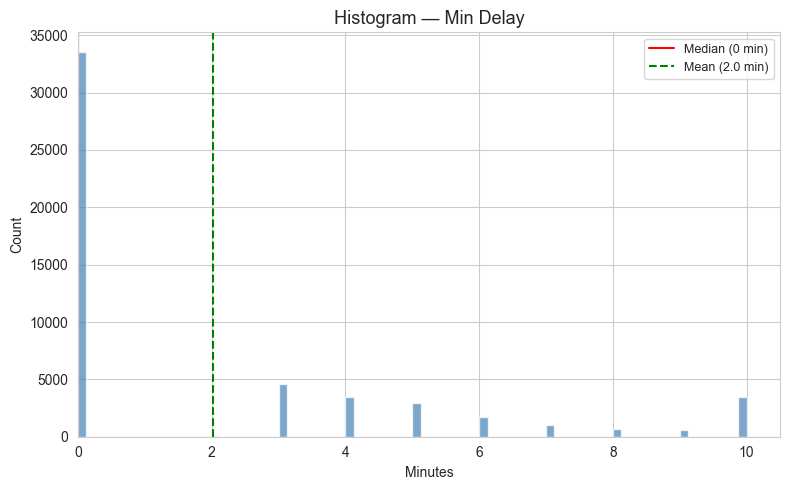

In [36]:
# Histogram — Min Delay
plt.figure(figsize=(8, 5))
plt.hist(df['min_delay_capped'], bins=80, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(df['min_delay_capped'].median(), color='red', linestyle='-', linewidth=1.5,
            label=f'Median ({df["min_delay_capped"].median():.0f} min)')
plt.axvline(df['min_delay_capped'].mean(), color='green', linestyle='--', linewidth=1.5,
            label=f'Mean ({df["min_delay_capped"].mean():.1f} min)')
plt.title('Histogram — Min Delay', fontsize=13)
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.legend(fontsize=9)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

In [37]:
df.shape

(52065, 12)

### 2.4 Drop Irrelevant Columns

| Column | Reason for dropping |
|--------|--------------------|
| `_id` | Database identifier, 50% null, no predictive value |
| `Vehicle` | Fleet number — individual vehicles don't consistently cause delays |
| `Bound` | 36% null, not needed for Phase 1 |
| `Time` | Will be replaced by extracted `hour` feature |
| `Day` | Will be replaced by extracted `day_of_week` feature |

In [38]:
df = df.drop(columns=['_id', 'Vehicle', 'Bound'])
print(f"Remaining Columns  are: {df.columns.tolist()}")

Remaining Columns  are: ['Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Line', 'min_delay_capped']


## Create the Target Varible

In [ ]:
df.head(10)

We need to tell the model what we are trying to predict.
Our question is: **"Was there a delay?"**

- If `Min Delay > 0` → there was a delay → we store **1**
- If `Min Delay = 0` → no delay → we store **0**

This new column is called `delay_occurred` and it is our **target variable**.

In [ ]:
df['delay_occured'] = (df['Min Delay'] > 0).astype(int)

In [41]:
df.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Line,min_delay_capped,delay_occured
0,2024-01-01 00:00:00,02:00,Monday,SHEPPARD STATION,MUI,0,0,Line 1,0,0
1,2024-01-01 00:00:00,02:00,Monday,DUNDAS STATION,MUIS,0,0,Line 1,0,0
2,2024-01-01 00:00:00,02:08,Monday,DUNDAS STATION,MUPAA,4,10,Line 1,4,1
3,2024-01-01 00:00:00,02:13,Monday,KENNEDY BD STATION,PUTDN,10,16,Line 2,10,1
4,2024-01-01 00:00:00,02:22,Monday,BLOOR STATION,MUPAA,4,10,Line 1,4,1


In [43]:
print(df['delay_occured'].value_counts())

0    33580
1    18485
Name: delay_occured, dtype: int64


In [44]:
# Show the percentage of each
print(df['delay_occured'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


0    64.5%
1    35.5%
Name: delay_occured, dtype: object


## Feature Engineering
Our model cannot understand raw text like `"Monday"` or `"08:30"`.
We need to convert our columns into **numbers** that the model can work with.

We will extract and convert the following features:
- `hour` → extracted from the `Time` column
- `day_num` → convert day name to a number (Monday = 0, Sunday = 6)
- `station_code` → convert each station name to a number
- `line_code` → convert each line name to a number

In [46]:
df['hour'] = df['Time'].apply(lambda t: int(t.split(':')[0]))
print(df[['Time', 'hour']].head())

    Time  hour
0  02:00     2
1  02:00     2
2  02:08     2
3  02:13     2
4  02:22     2


#### Convert Day Name to a Number

The model cannot read the word `"Monday"`.
We create a dictionary that maps each day to a number, starting from 0.


In [47]:
# Map each day name to a number
# Monday = 0, Tuesday = 1. Wednesday =2 ..etc
day_mapping = {
    'Monday':0,
    'Tuesday':1,
    'Wednesday':2,
    'Thursday':3,
    'Friday':4,
    'Saturday':5,
    'Sunday':6
}

df['day_num'] = df['Day'].map(day_mapping)
print(df[['Day', 'day_num']].head())


      Day  day_num
0  Monday        0
1  Monday        0
2  Monday        0
3  Monday        0
4  Monday        0


#### Convert Station Name to a Number

There are many stations in our dataset.
We use `LabelEncoder` which automatically assigns a unique number to each station name.
For example: `"BLOOR STATION"` → `5`, `"DUNDAS STATION"` → `12`

In [48]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

df['station_code'] = le.fit_transform(df['Station'])

# Check it worked
print(df[['Station', 'station_code']].drop_duplicates().head(10))

                  Station  station_code
0        SHEPPARD STATION           442
1          DUNDAS STATION           111
3      KENNEDY BD STATION           244
4           BLOOR STATION            34
5        ST CLAIR STATION           482
7        WOODBINE STATION           658
8           FINCH STATION           160
9      DAVISVILLE STATION            87
11        COLLEGE STATION            68
12  LAWRENCE WEST STATION           307


#### Convert Line Name to a Number

Same idea as Station — we convert the line name to a number so the model can understand it.

In [49]:
df.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Line,min_delay_capped,delay_occured,hour,day_num,station_code
0,2024-01-01 00:00:00,02:00,Monday,SHEPPARD STATION,MUI,0,0,Line 1,0,0,2,0,442
1,2024-01-01 00:00:00,02:00,Monday,DUNDAS STATION,MUIS,0,0,Line 1,0,0,2,0,111
2,2024-01-01 00:00:00,02:08,Monday,DUNDAS STATION,MUPAA,4,10,Line 1,4,1,2,0,111
3,2024-01-01 00:00:00,02:13,Monday,KENNEDY BD STATION,PUTDN,10,16,Line 2,10,1,2,0,244
4,2024-01-01 00:00:00,02:22,Monday,BLOOR STATION,MUPAA,4,10,Line 1,4,1,2,0,34


In [50]:
df["line_num"] = le.fit_transform(df["Line"])
print(df[["Line", "line_num"]].drop_duplicates().head())

          Line  line_num
0       Line 1         0
3       Line 2         3
46    Line 1/2         1
121     Line 4         5
7736    Line 3         4


#### Calculate Historical Delay Rate per Station and Hour

For each combination of station and hour, we calculate how often a delay happened historically.
This tells the model: *"At this station, at this time of day, delays happen X% of the time."*
This is a strong signal for predicting whether a delay will occur.

In [53]:
# Calculate the hestorical delay rate for each station + hour combination
delay_rate = df.groupby(['Station','hour'])['delay_occured'].mean()

In [ ]:
delay_rate

In [59]:

# Ad it as a new column in our dataframe
df['delay_rate'] = df.set_index(['Station', 'hour']).index.map(delay_rate)

# Check it worked
print(df[['Station', 'hour', 'delay_occured', 'delay_rate']].head(10))


              Station  hour  delay_occured  delay_rate
0    SHEPPARD STATION     2              0    0.090909
1      DUNDAS STATION     2              0    0.125000
2      DUNDAS STATION     2              1    0.125000
3  KENNEDY BD STATION     2              1    0.046296
4       BLOOR STATION     2              1    0.200000
5    ST CLAIR STATION     2              1    0.333333
6       BLOOR STATION     2              0    0.200000
7    WOODBINE STATION     2              1    0.285714
8       FINCH STATION     2              0    0.047244
9  DAVISVILLE STATION     2              1    0.571429


In [ ]:
df.head()

In [62]:
df_clean = df.copy()
df_model = df.drop(columns=['Date', 'Time', 'Day', 'Station', 'Line', 'Code', 'Min Gap'])
print(df_model.columns.tolist())

['Min Delay', 'min_delay_capped', 'delay_occured', 'hour', 'day_num', 'station_code', 'line_num', 'delay_rate']


In [65]:
df_model.head()

,Min Delay,min_delay_capped,delay_occured,hour,day_num,station_code,line_num,delay_rate
0,0,0,0,2,0,442,0,0.090909
1,0,0,0,2,0,111,0,0.125000
2,4,4,1,2,0,111,0,0.125000
3,10,10,1,2,0,244,3,0.046296
4,4,4,1,2,0,34,0,0.200000


In [66]:
# Features - What the model uses to make a prediction
X = df_model[['hour', 'day_num', 'station_code', 'line_num', 'delay_rate']]
# Target - What we want to predict (1 = delay, 0 = no delay)
y = df_model['delay_occured']


In [67]:
X.head()

,hour,day_num,station_code,line_num,delay_rate
0,2,0,442,0,0.090909
1,2,0,111,0,0.125000
2,2,0,111,0,0.125000
3,2,0,244,3,0.046296
4,2,0,34,0,0.200000


In [68]:
y.head()

0    0
1    0
2    1
3    1
4    1
Name: delay_occured, dtype: int32

###  Split Data into Training and Testing Sets

We split our data into two parts:
- **Training set (80%)** → the model learns from this
- **Testing set (20%)** → we use this to check how well the model learned

We never let the model see the testing set during training.
This way we can trust our results.


In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 41652
Testing rows: 10413


## Train the Model

We will use a **Random Forest** model.

Think of it like asking 100 different people the same question and going with the most popular answer.
Each "person" is a decision tree that looks at the data differently.
Together they make a stronger and more accurate prediction than any single tree alone.


In [71]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
model_rf = RandomForestClassifier(
    n_estimators = 100, # use 100 decision tree
    random_state = 42
)

# Train the model on the training data
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

###  Evaluate the Model

We test the model on data it has never seen before (the 20% test set).

We use three measures instead of just accuracy:
- **Precision** → out of all the delays the model predicted, how many were actually delays?
- **Recall** → out of all the real delays, how many did the model catch?
- **F1-Score** → a balance between precision and recall (the higher the better)


In [72]:
from sklearn.metrics import classification_report

# Use the model to predict on the test set
y_pred = model_rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Delay', 'Delay']))

              precision    recall  f1-score   support

    No Delay       0.69      0.77      0.73      6662
       Delay       0.49      0.38      0.43      3751

    accuracy                           0.63     10413
   macro avg       0.59      0.58      0.58     10413
weighted avg       0.62      0.63      0.62     10413



### Understanding the Model Results

We tested the model on **10,413 records** it had never seen before.
Here is what the numbers mean:

---

#### What is Precision?
Out of all the times the model predicted a delay — how many were actually delays?
- **No Delay: 0.69** → when the model said "no delay", it was right 69% of the time
- **Delay: 0.49** → when the model said "delay", it was only right 49% of the time

#### What is Recall?
Out of all the real delays in the data — how many did the model catch?
- **No Delay: 0.77** → the model correctly identified 77% of all real "no delay" cases
- **Delay: 0.38** → the model only caught 38% of all real delays — it missed 62% of them

#### What is F1-Score?
A single number that balances precision and recall. Closer to 1.0 is better.
- **No Delay: 0.73** → the model is reasonably good at predicting no delay
- **Delay: 0.43** → the model is weak at predicting actual delays

#### Overall Accuracy: 63%
The model got 63% of all predictions correct.
This sounds okay, but it is not much better than always guessing "no delay"
which would give 64.5% accuracy — because 64.5% of our data has no delay.

---

#### Conclusion
The model struggles to predict delays reliably.
This is because many subway delays are caused by random events
(medical emergencies, mechanical faults) that do not follow a clear pattern.
A score of 63% is close to the limit of what time and location features alone can predict.